# 00

In [1]:
import os
PROJECT_ROOT = "/home/dotamthuc-3090/Projects/ViewSynthesis/"
print("PROJECT_ROOT:", PROJECT_ROOT)

import sys
lib_decompre = "/home/dotamthuc-3090/Projects/ViewSynthesis/Differentiable3DPC-Decompression-and-Rendering"
sys.path.insert(0, lib_decompre)

lib_svraster = "/home/dotamthuc-3090/Projects/ViewSynthesis/svraster"
sys.path.insert(0, lib_svraster)

import itertools
import numpy as np
import torch
from matplotlib.pylab import plt

from libs.dataloader.View import View, ViewCreator
from libs.dataloader.Scene import Scene

import decompress_render

from src.dataloader.data_pack import DataPack
from src.sparse_voxel_model import SparseVoxelModel
from src.config import cfg, update_argparser, update_config

PROJECT_ROOT: /home/dotamthuc-3090/Projects/ViewSynthesis/


In [2]:
source_path = "/home/dotamthuc-3090/Projects/ViewSynthesis/data/360_v2/kitchen/"
scene_dataset = Scene(
    source_path, image_dir_name="images",
    res_downscale=3.5, res_width=0,
    test_every=-1
)

train_views = scene_dataset.get_train_views()
test_views = scene_dataset.get_test_views()
len(train_views), len(test_views)

Read dataset in COLMAP format.


(279, 0)

In [3]:
# Init voxel model
voxel_model = SparseVoxelModel(
    n_samp_per_vox=3,
    sh_degree=0,
    ss=1.5,
    white_background=True,
    black_background=False,
)
voxel_model.load_iteration("/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v03", 95000)
voxel_model.freeze_vox_geo()

morton_code_tensor = voxel_model.vox_morton_code.clone().detach()
vox_roots_tensor = voxel_model.vox_root.clone().detach()
vox_length_tensor = voxel_model.vox_size.clone().detach()
vox2corners_tensor = voxel_model.vox_key.clone().detach()
vox_params_geo_tensor = voxel_model.vox_conners_geo_params.clone().detach()
vox_params_color_tensor = voxel_model.vox_static_rgbs.clone().detach()

print(f"morton_code_tensor={morton_code_tensor.shape, morton_code_tensor.dtype}")
print(f"vox_roots_tensor={vox_roots_tensor.shape, vox_roots_tensor.dtype}")
print(f"vox_length_tensor={vox_length_tensor.shape, vox_length_tensor.dtype}")
print(f"vox2corners_tensor={vox2corners_tensor.shape, vox2corners_tensor.dtype}")
print(f"vox_params_geo_tensor={vox_params_geo_tensor.shape, vox_params_geo_tensor.dtype}")
print(f"vox_params_color_tensor={vox_params_color_tensor.shape, vox_params_color_tensor.dtype}")

morton_code_tensor=(torch.Size([9749024, 1]), torch.int64)
vox_roots_tensor=(torch.Size([9749024, 3]), torch.float32)
vox_length_tensor=(torch.Size([9749024, 1]), torch.float32)
vox2corners_tensor=(torch.Size([9749024, 8]), torch.int64)
vox_params_geo_tensor=(torch.Size([16611122, 1]), torch.float32)
vox_params_color_tensor=(torch.Size([9749024, 3]), torch.float32)


In [4]:
a_view = train_views[0]
ss = 1.0

w_src, h_src = a_view.render_width, a_view.render_height
w, h = round(w_src * ss), round(h_src * ss)
w_ss, h_ss = w / w_src, h / h_src

camera_settings = decompress_render.renderer.CameraSettings(
    image_width=w, 
    image_height=h, 
    tanfovx=a_view.tanfovx, 
    tanfovy=a_view.tanfovy, 
    cx=a_view.cx * w_ss,
    cy=a_view.cy * h_ss,
    w2c_matrix=a_view.world2view.cuda(),
    c2w_matrix=a_view.view2world.cuda()
)

render_settings = decompress_render.renderer.RenderSettings(
    num_sample_per_vox=3,
    bg_color=float(voxel_model.white_background),
    near=a_view.near,
    need_depth=True,
    track_max_w=False,
    debug=True,
)


N: 9749024 


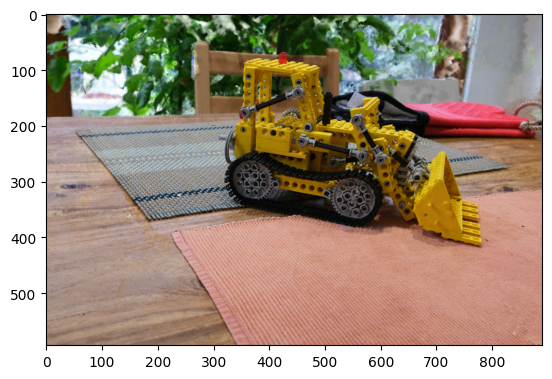

In [5]:
result_rendered = decompress_render.renderer.rasterize_voxels_main(
    camera_settings=camera_settings,
    render_settings=render_settings,
    morton_code=morton_code_tensor,
    vox_roots=vox_roots_tensor,
    vox_length=vox_length_tensor,
    vox2corners=vox2corners_tensor,
    vox_params_geo=vox_params_geo_tensor,
    vox_params_color=vox_params_color_tensor,
)

img_out = torch.permute(result_rendered[0].clamp(0, 1), dims=(1, 2, 0)).detach().cpu().numpy()
plt.imshow(img_out)

# 01

In [1]:
import os
PROJECT_ROOT = "/home/dotamthuc-3090/Projects/ViewSynthesis/"
print("PROJECT_ROOT:", PROJECT_ROOT)

import sys
lib_decompre = "/home/dotamthuc-3090/Projects/ViewSynthesis/Differentiable3DPC-Decompression-and-Rendering"
sys.path.insert(0, lib_decompre)

lib_svraster = "/home/dotamthuc-3090/Projects/ViewSynthesis/svraster"
sys.path.insert(0, lib_svraster)

import itertools
import numpy as np
import torch
from matplotlib.pylab import plt

from libs.dataloader.View import View, ViewCreator
from libs.dataloader.Scene import Scene

import decompress_render

from src.dataloader.data_pack import DataPack
from src.sparse_voxel_model import SparseVoxelModel
from src.config import cfg, update_argparser, update_config

PROJECT_ROOT: /home/dotamthuc-3090/Projects/ViewSynthesis/


In [ ]:
def get_polynomials_coefs_sqrtinv(max_degree):
    list_b = [1]
    temp = 1
    for n in range(1, max_degree+1):
        temp *= (2 * n - 1) / (2 * n)
        list_b.append(temp)

    return np.array(list_b, np.float32)


def load_geometry_from_sparse_voxels_model(sourse_path, load_attribute_field=True):
    voxel_model_frame = SparseVoxelModel(
        n_samp_per_vox=1,
        sh_degree=0,
        ss=1.0,
        white_background=False,
        black_background=True,
    )
    voxel_model_frame.load(sourse_path)

    geometry_info = {}
    geometry_info["morton_code_tensor"] = voxel_model_frame.vox_morton_code.clone().detach()
    geometry_info["vox_roots_tensor"] = voxel_model_frame.vox_root.clone().detach()
    geometry_info["vox_length_tensor"] = voxel_model_frame.vox_size.clone().detach()
    geometry_info["vox2corners_tensor"] = voxel_model_frame.vox_key.clone().detach()
    geometry_info["vox_params_geo_tensor"] = voxel_model_frame.vox_conners_geo_params.clone().detach()

    if load_attribute_field:
        geometry_info["vox_params_color_tensor"] = voxel_model_frame.vox_static_rgbs.clone().detach()

    del voxel_model_frame
    torch.cuda.empty_cache()

    return geometry_info


class DensityField:
    def __init__(
        self,
        source_path,
        num_sample_per_voxel=1,
        load_attribute_field=True
    ):
        # CONFIG INFO
        self.num_sample_per_voxel = num_sample_per_voxel

        geometry_info = load_geometry_from_sparse_voxels_model(source_path, load_attribute_field)
        #### Define the Density Field
        self.voxel_morton_code = geometry_info["morton_code_tensor"]
        self.voxel_position    = geometry_info["vox_roots_tensor"]
        self.voxel_size        = geometry_info["vox_length_tensor"]
        self.voxel2corner      = geometry_info["vox2corners_tensor"]
        self.corner_geo_params = geometry_info["vox_params_geo_tensor"]
        self.num_voxels        = self.voxel_morton_code.shape[0]

        #### Define current Attribute Field
        if load_attribute_field:
            self.voxel_attribute_field = geometry_info["vox_params_color_tensor"]
        else:
            self.voxel_attribute_field = torch.full(
                [self.num_voxels, 3], 0.5, 
                dtype=torch.float32
            )
    
    def apply_phi(self, view_info):

        w, h = view_info.render_width, view_info.render_height

        camera_settings = decompress_render.renderer.CameraSettings(
            image_width=view_info.render_width, 
            image_height=view_info.render_height, 
            tanfovx=view_info.tanfovx, 
            tanfovy=view_info.tanfovy, 
            cx=view_info.cx,
            cy=view_info.cy,
            w2c_matrix=view_info.world2view.cuda(),
            c2w_matrix=view_info.view2world.cuda()
        )

        render_settings = decompress_render.renderer.RenderSettings(
            num_sample_per_vox=self.num_sample_per_voxel,
            bg_color=0.0,
            near=view_info.near,
            need_depth=False,
            track_max_w=False,
            debug=False,
        )

        out_color, _, _, _ = decompress_render.renderer.rasterize_voxels_main(
            camera_settings=camera_settings,
            render_settings=render_settings,
            morton_code=self.voxel_morton_code,
            vox_roots=self.voxel_position,
            vox_length=self.voxel_size,
            vox2corners=self.voxel2corner,
            vox_params_geo=self.corner_geo_params,
            vox_params_color=self.voxel_attribute_field,
        )

        rendered_image = torch.permute(out_color.clamp(0, 1), dims=(1, 2, 0)).detach()

        return rendered_image
    
    def apply_subview_phiTphi_with_F(self, voxel_attribute, view_info):

        w, h = view_info.render_width, view_info.render_height
        camera_settings = decompress_render.renderer.CameraSettings(
            image_width=view_info.render_width, 
            image_height=view_info.render_height, 
            tanfovx=view_info.tanfovx, 
            tanfovy=view_info.tanfovy, 
            cx=view_info.cx,
            cy=view_info.cy,
            w2c_matrix=view_info.world2view.cuda(),
            c2w_matrix=view_info.view2world.cuda()
        )

        render_settings = decompress_render.renderer.RenderSettings(
            num_sample_per_vox=self.num_sample_per_voxel,
            bg_color=0.0,
            near=view_info.near,
            need_depth=False,
            track_max_w=False,
            debug=False,
        )

        out_transformed_attribute = decompress_render.renderer.geometry_attention_transform_main(
            camera_settings=camera_settings,
            render_settings=render_settings,
            morton_code=self.voxel_morton_code,
            vox_roots=self.voxel_position,
            vox_length=self.voxel_size,
            vox2corners=self.voxel2corner,
            vox_params_geo=self.corner_geo_params,
            vox_params_attribute=voxel_attribute, # use as input voxel_attribute 
        )

        return out_transformed_attribute
    
    def apply_full_phiTphi_with_F(self, voxel_attribute, scene_dataset):

        if voxel_attribute.shape != (self.num_voxels, 3):
            raise Exception(f"Expect voxel_attribute in is static ({self.num_voxels}, 3) but got", voxel_attribute.shape)

        train_views = scene_dataset.get_train_views()
        transformed_attribute = torch.full(
            [self.num_voxels, 3], 0.0, 
            dtype=torch.float32, device="cuda"
        )
        for view in train_views:
            transformed_attribute = transformed_attribute + self.apply_subview_phiTphi_with_F(voxel_attribute, view)

        return transformed_attribute

    def apply_scaled_rotation_phiTphi(self, voxel_attribute, scene_dataset):
        output = torch.full(
            [self.num_voxels, 3], 0.0, 
            dtype=torch.float32, device="cuda"
        )

        diagonal = self.apply_full_phiTphi_with_F(
            torch.ones_like(voxel_attribute), 
            scene_dataset
        ).detach()

        sqrtinv_diagonal = torch.where(
            diagonal>0.0,
            1.0 / torch.sqrt(diagonal),
            1.0
        )

        polynomials_coefs_sqrtinv = get_polynomials_coefs_sqrtinv(10)


        return output
    
    def apply_phi_with_F(self, voxel_attribute, view_info):

        if voxel_attribute.shape != (self.num_voxels, 3):
            raise Exception(f"Expect voxel_attribute in is static voxels color ({self.num_voxels}, 3) but got", voxel_attribute.shape)

        w, h = view_info.render_width, view_info.render_height
        camera_settings = decompress_render.renderer.CameraSettings(
            image_width=view_info.render_width, 
            image_height=view_info.render_height, 
            tanfovx=view_info.tanfovx, 
            tanfovy=view_info.tanfovy, 
            cx=view_info.cx,
            cy=view_info.cy,
            w2c_matrix=view_info.world2view.cuda(),
            c2w_matrix=view_info.view2world.cuda()
        )

        render_settings = decompress_render.renderer.RenderSettings(
            num_sample_per_vox=self.num_sample_per_voxel,
            bg_color=0.0,
            near=view_info.near,
            need_depth=False,
            track_max_w=False,
            debug=False,
        )

        out_color, _, _, _ = decompress_render.renderer.rasterize_voxels_main(
            camera_settings=camera_settings,
            render_settings=render_settings,
            morton_code=self.voxel_morton_code,
            vox_roots=self.voxel_position,
            vox_length=self.voxel_size,
            vox2corners=self.voxel2corner,
            vox_params_geo=self.corner_geo_params,
            vox_params_color=voxel_attribute, # use as input voxel_attribute 
        )

        rendered_image = torch.permute(out_color.clamp(0, 1), dims=(1, 2, 0))

        return rendered_image

    def apply_A_transpose(
            self,
            lowres_denfield,
            scene_dataset,
            optim_opt={}
        ):

        MSE_calculator = torch.nn.MSELoss()

        approx_attribute_field = torch.nn.Parameter(torch.full(
            [self.num_voxels, 3], 0.5, 
            dtype=torch.float32, device="cuda"
        ))
        optimizer = torch.optim.Adam([approx_attribute_field], lr=optim_opt.get("lr", 0.001))
        train_views = scene_dataset.get_train_views()

        i=0
        for loop in range(optim_opt.get("num_scene_loop", 30)):
            for view in train_views:
                ##
                optimizer.zero_grad()
                true_low_res_img   = lowres_denfield.apply_phi(view)
                approx_low_res_img = self.apply_phi_with_F(approx_attribute_field, view)
                ###
                mse_val = MSE_calculator(approx_low_res_img, true_low_res_img)
                mse_val.backward()
                ###
                print(f"loop = {loop} iter = {i} psnr={-10 * np.log10(mse_val.detach().cpu())}")
                optimizer.step()
                i+=1

        output = approx_attribute_field.detach()
        
        # Cleaning
        optimizer.zero_grad()
        del optimizer
        torch.cuda.empty_cache()

        return output


class MultiScaleSplatsEncoder:
    def __init__(
        self,
        scene_dataset_source_path,
        list_density_field_paths,
        num_sample_per_voxel=1,
        scene_loader_opt={
            "res_downscale": 3.5,
            "res_width": 0,
        },
        A_transpose_opt={
            "lr": 0.001,
            "num_scene_loop": 20,
        }
    ):
        
        self.list_density_field = []
        for path in list_density_field_paths:
            self.list_density_field.append(
                DensityField(path, num_sample_per_voxel, load_attribute_field=True)
            )

        self.scene_dataset = Scene(
            scene_dataset_source_path, image_dir_name="images",
            res_downscale=scene_loader_opt["res_downscale"],
            res_width=scene_loader_opt["res_width"],
            test_every=-1
        )

        self.A_transpose_opt=A_transpose_opt

    def test_encoding(self):
        list_residual_gap = []
        L = len(self.list_density_field)
        for i in range(1, L, 1):
            lowres_denfield = self.list_density_field[i-1]
            highres_denfield = self.list_density_field[i]

            approx_attribute_field = highres_denfield.apply_A_transpose(
                lowres_denfield,
                self.scene_dataset,
                optim_opt=self.A_transpose_opt
            )

            ### FOR TESTING 
            residual_gap = highres_denfield.voxel_attribute_field - approx_attribute_field
            list_residual_gap.append(
                residual_gap
            )

        return list_residual_gap

In [4]:
source_path = "/home/dotamthuc-3090/Projects/ViewSynthesis/data/360_v2/kitchen/"
scene_dataset = Scene(
    source_path, image_dir_name="images",
    res_downscale=3.5, res_width=0,
    test_every=-1
)

train_views = scene_dataset.get_train_views()
test_views = scene_dataset.get_test_views()
len(train_views), len(test_views)

Read dataset in COLMAP format.


(279, 0)

In [4]:
high_res = DensityField("/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v03/checkpoints/iter045999_model.pt")
low_res = DensityField("/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v03/checkpoints/iter013999_model.pt")

approx_attribute_field = high_res.apply_A_transpose(
    low_res,
    scene_dataset,
    optim_opt={
        "lr": 0.001,
        "num_scene_loop": 20
    }
)


loop = 0 iter = 0 psnr=13.129465103149414
loop = 0 iter = 1 psnr=13.043323516845703
loop = 0 iter = 2 psnr=12.98413372039795
loop = 0 iter = 3 psnr=13.058042526245117
loop = 0 iter = 4 psnr=13.03803539276123
loop = 0 iter = 5 psnr=13.064242362976074
loop = 0 iter = 6 psnr=12.970726013183594
loop = 0 iter = 7 psnr=12.96388053894043
loop = 0 iter = 8 psnr=12.91481876373291
loop = 0 iter = 9 psnr=12.980405807495117
loop = 0 iter = 10 psnr=12.952509880065918
loop = 0 iter = 11 psnr=13.026165962219238
loop = 0 iter = 12 psnr=13.09043025970459
loop = 0 iter = 13 psnr=13.235773086547852
loop = 0 iter = 14 psnr=13.337555885314941
loop = 0 iter = 15 psnr=13.406850814819336
loop = 0 iter = 16 psnr=13.416099548339844
loop = 0 iter = 17 psnr=13.5077486038208
loop = 0 iter = 18 psnr=13.71335506439209
loop = 0 iter = 19 psnr=13.795684814453125
loop = 0 iter = 20 psnr=13.649616241455078
loop = 0 iter = 21 psnr=13.697403907775879
loop = 0 iter = 22 psnr=13.453302383422852
loop = 0 iter = 23 psnr=13.31

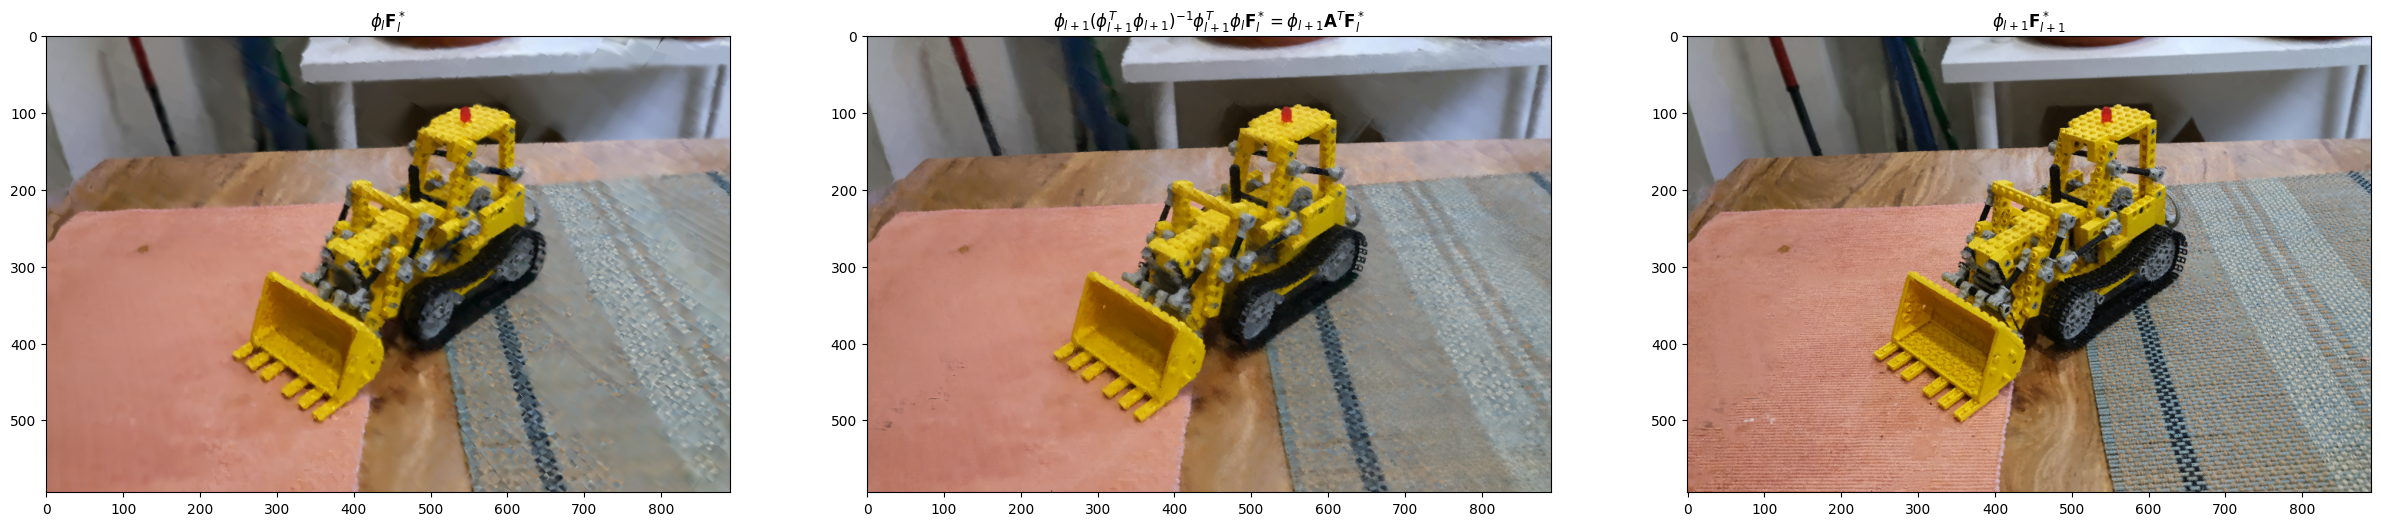

In [7]:
rendered_img_low = low_res.apply_phi(train_views[100]).cpu().numpy()
rendered_img_high = high_res.apply_phi(train_views[100]).cpu().numpy()
rendered_img_low_approx = high_res.apply_phi_with_F(approx_attribute_field, train_views[100]).detach().cpu().numpy()

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(30, 10))
ax[0].imshow(rendered_img_low)
ax[0].set_title(r"$\phi_l \mathbf{F}_l^*$")
ax[1].imshow(rendered_img_low_approx)
ax[1].set_title(r"$\phi_{l+1} (\phi_{l+1}^T\phi_{l+1})^{-1} \phi_{l+1}^T\phi_l \mathbf{F}_l^* = \phi_{l+1} \mathbf{A}^T \mathbf{F}_l^*$")
ax[2].imshow(rendered_img_high)
ax[2].set_title(r"$\phi_{l+1} \mathbf{F}_{l+1}^*$")

# err = np.clip(np.abs(rendered_img_low_approx-rendered_img_low) / rendered_img_low_approx, 0.0, 1.0)
# ax[3].imshow(err)

plt.show()

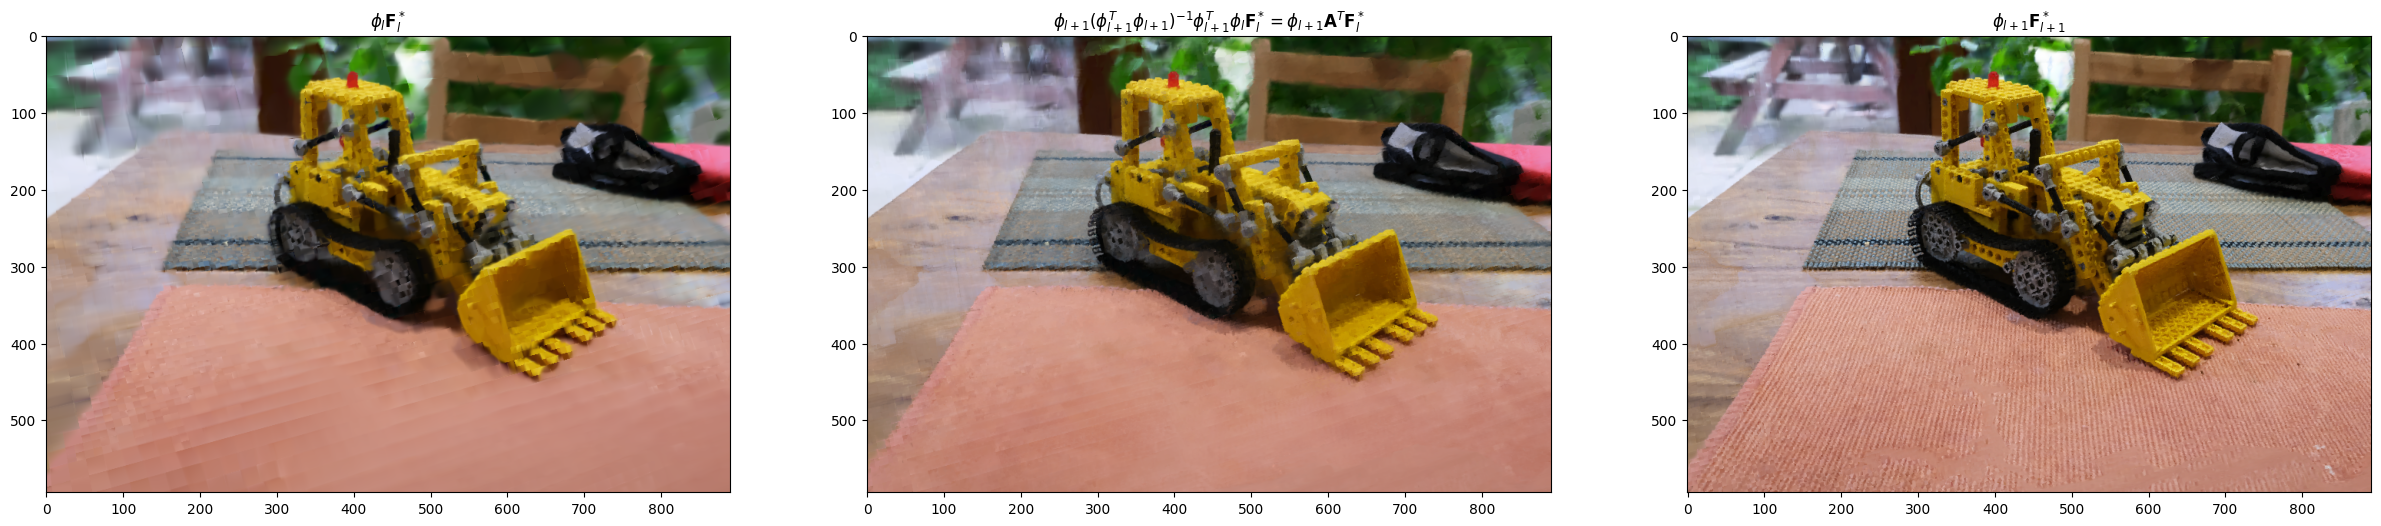

In [8]:
rendered_img_low = low_res.apply_phi(train_views[10]).cpu().numpy()
rendered_img_high = high_res.apply_phi(train_views[10]).cpu().numpy()
rendered_img_low_approx = high_res.apply_phi_with_F(approx_attribute_field, train_views[10]).detach().cpu().numpy()

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(30, 10))
ax[0].imshow(rendered_img_low)
ax[0].set_title(r"$\phi_l \mathbf{F}_l^*$")
ax[1].imshow(rendered_img_low_approx)
ax[1].set_title(r"$\phi_{l+1} (\phi_{l+1}^T\phi_{l+1})^{-1} \phi_{l+1}^T\phi_l \mathbf{F}_l^* = \phi_{l+1} \mathbf{A}^T \mathbf{F}_l^*$")
ax[2].imshow(rendered_img_high)
ax[2].set_title(r"$\phi_{l+1} \mathbf{F}_{l+1}^*$")

# err = np.clip(np.abs(rendered_img_low_approx-rendered_img_low) / rendered_img_low_approx, 0.0, 1.0)
# ax[3].imshow(err)

plt.show()

In [ ]:
low_res = DensityField("/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v03/checkpoints/iter013999_model.pt")

temp_list = []

for i in range(100):
    attribute = torch.zeros_like(low_res.voxel_attribute_field)
    attribute[i, 0]=1
    transformed_attribute = torch.zeros_like(low_res.voxel_attribute_field)
    for view in train_views:
        transformed_attribute = transformed_attribute + low_res.apply_subview_phiTphi_with_F(attribute, view).detach()

    temp_list.append(transformed_attribute[:100, 0])
    if i%10==0:
        print(f"Done {i}")


Done 0
Done 10
Done 20
Done 30
Done 40
Done 50
Done 60
Done 70
Done 80
Done 90


In [55]:
temp_m = torch.stack(temp_list, axis=1)


In [56]:
temp_m.shape

torch.Size([100, 100])

In [51]:
temp_m[:20, :20].cpu().numpy()

array([[7.463e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 2.919e-02, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00],
       [0.000e+00, 2.214e+01, 2.457e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00],
       [0.000e+00, 2.457e+00, 1.078e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 3.099e-03, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00],
       [0.000e+00, 0.000e+00, 0.000e+00, 1.671e+02, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00],
       [0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 8.544e-01, 0.000e+00, 5.905e-01,

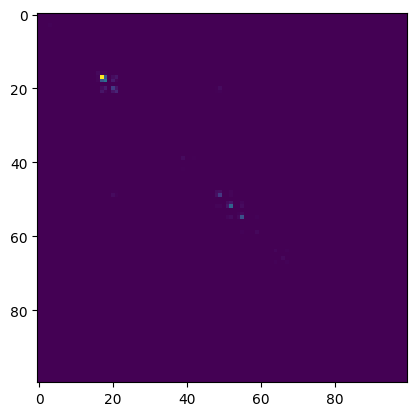

In [57]:
plt.imshow(temp_m[:100, :100].cpu().numpy())

In [ ]:
low_res = DensityField("/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v03/checkpoints/iter013999_model.pt")

temp_list = []

attribute =  torch.nn.Parameter(torch.full(
    [low_res.num_voxels, 3], 1.0, 
    dtype=torch.float32, device="cuda"
))


transformed_attribute = torch.zeros_like(low_res.voxel_attribute_field)
for view in train_views:
    transformed_attribute = transformed_attribute + low_res.apply_subview_phiTphi_with_F(attribute, view)




In [92]:
transformed_attribute.sum().backward()

In [93]:
attribute.grad.min(), attribute.grad.max(), attribute.grad

(tensor(0., device='cuda:0'),
 tensor(56267.8164, device='cuda:0'),
 tensor([[2.5151e+03, 2.5151e+03, 2.5151e+03],
         [1.9051e-01, 1.9051e-01, 1.9051e-01],
         [5.1643e+00, 5.1643e+00, 5.1643e+00],
         ...,
         [4.8983e+00, 4.8983e+00, 4.8983e+00],
         [3.3571e+02, 3.3571e+02, 3.3571e+02],
         [3.8899e+01, 3.8899e+01, 3.8899e+01]], device='cuda:0'))

(array([45277., 10645.,  5525.,  2436.,  1312.,   776.,   544.,   383.,   244.,   172.]),
 array([    0.,  2000.,  4000.,  6000.,  8000., 10000., 12000., 14000., 16000., 18000., 20000.]),
 <BarContainer object of 10 artists>)

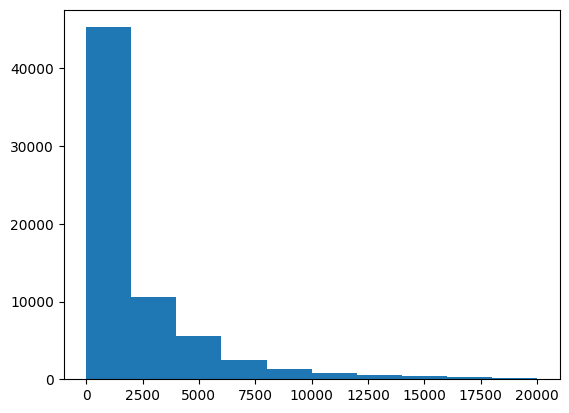

In [66]:
plt.hist(transformed_attribute[:, 0].cpu().numpy(), range=(0, 20000))

(array([45277., 10645.,  5525.,  2436.,  1312.,   776.,   544.,   383.,   244.,   172.]),
 array([    0.,  2000.,  4000.,  6000.,  8000., 10000., 12000., 14000., 16000., 18000., 20000.]),
 <BarContainer object of 10 artists>)

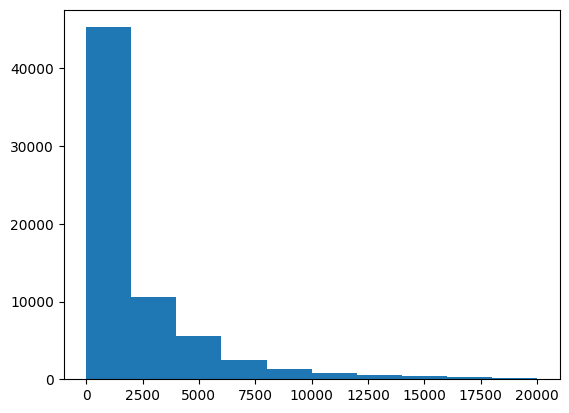

In [94]:
plt.hist(attribute.grad[:, 0].cpu().numpy(), range=(0, 20000))

In [38]:
np.set_printoptions(
    precision=3,        # Number of digits of precision for floating point output
    suppress=False,      # Suppress scientific notation
    threshold=10000,    # Print the full array if it has fewer than 10000 elements
    linewidth=1000       # Number of characters per line
)